# Predicción de Precios de Autos Usados
## Trabajo Final — Aprendizaje de Máquina

---

| Campo | Detalle |
|---|---|
| **Materia** | Aprendizaje de Máquina |
| **Institución** | Laboratorio de Sistemas Embebidos - Facultad de Ingeniería — UBA |
| **Dataset** | [Vehicle dataset](https://www.kaggle.com/datasets/nehalbirla/vehicle-dataset-from-cardekho/data) — Kaggle |

---


| Integrante | Legajo |
|---|---|
| Marcos Lund | a2408 |
| Tomás Mc Nally | a2420 |
| Alan Vignolo | a2418 |
| Agustin Biancardi | a2403 |


---

### Resumen 

Este trabajo busca predecir el precio de autos usados dadas las características de los autos. A partir de un dataset con características vehiculares —kilometraje, potencia, antigüedad, marca, ubicación y features ingenierizadas en una etapa previa de EDA—, seguimos una metodología en dos fases:

1. **Modelo Baseline:** Se definió una heurística base como línea base comparativa
2. **Evaluación Out-of-the-Box (OOB):** Entrenamos modelos con parámetros por defecto para establecer los algoritmos que mejor se ajustan al tipo de problema
3. **Ajuste de hiperparámetros:** Ajustamos los hiperparámetros de los mejores modelos OOB

El objetivo final es identificar qué técnica ofrece el mejor rendimiento predictivo y reflexionar sobre posibles mejoras y extensiones de la investigación.

---

> 📌 **Nota de reproducibilidad:** El notebook utiliza un sistema de caché (`joblib`) y base de datos SQLite (`optuna.db`) para evitar recómputo al volver a ejecutar las celdas. Los resultados son completamente reproducibles desde cero eliminando las carpetas `cache/` y `optuna.db`.

> **Aviso:** la **conclusión ampliada** (contexto Cardekho, explicación por modelos, SHAP, *predicho vs real*) está al **final** del notebook: [Conclusiones](#commentary-and-conclusions).


## Índice
1. [Imports](#Imports)

2. [Funciones Auxiliares](#Funciones-Auxiliares)

3. [Entrenamiento inicial de modelos OOB](#Entrenamiento-inicial-con-modelos-OOB-(out-of-the-box))

4. [Ajuste de Hiperparámetros](#hyperparameter-tuning)

5. [Conclusiones](#commentary-and-conclusions) (al final: textos ampliados + SHAP + residuos) (al final: textos ampliados + SHAP + residuos) (sección al **final** del notebook: hallazgos ampliados, gráfico SHAP con interpretación y diagnóstico *predicho vs real*)

# Imports

In [1]:

## data manipulation and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import joblib

## xgboost 
import xgboost as xgb

## lightgbm
import lightgbm as lgb

import optuna

## sklearn imports
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.ensemble import AdaBoostRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    r2_score,
    root_mean_squared_error,
)
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    train_test_split,
    learning_curve,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

### Preprocesamiento previo (`TPFinal_Parte1.ipynb`)

El dataset fue tratado en un notebook de EDA separado antes de este archivo. 

Inicialmente tenemos dos variantes del dataset, para evaluar si es o no es útil usar PCA.

- **Full features** — El resultado de realizar feature Engineer sobre las variables originales (`train_data.csv` / `test_data.csv`)
- **PCA features** — Agregando el paso de realizar un análisis de componentes principales (`pca_train_data.csv` / `pca_test_data.csv`)

In [2]:
# loading data
train_df = pd.read_csv("../datasets/train_data.csv")
test_df = pd.read_csv("../datasets/test_data.csv")

print(f"Size of train_df: {train_df.shape}")
print(f"Size of test_df: {test_df.shape}")
train_df.head()

Size of train_df: (1536, 15)
Size of test_df: (393, 15)


,Price,Kilometer,Max Power,Height,Seating Capacity,Age,Make_freq,Location_freq,Fuel Type_Petrol,Transmission_Manual,Seller Type_Individual,Drivetrain_FWD,Drivetrain_RWD,Color_target,Owner_encoded
0,0.815806,0.931484,1.024759,-0.333531,-0.364918,0.168043,-0.691837,-1.070817,-0.929558,-1.107288,0.181528,-1.541371,2.301105,1.966224,-0.441446
1,-0.220541,2.176958,0.381760,1.444219,2.148597,-0.142190,-0.708657,-1.121652,-0.929558,0.903107,0.181528,0.648773,-0.434574,-1.336504,-0.441446
2,2.629126,-1.701804,2.305902,1.725696,2.148597,-1.383123,-0.321803,1.267591,-0.929558,-1.107288,0.181528,-1.541371,-0.434574,0.196895,-0.441446
3,1.291857,0.789144,0.899773,1.814584,2.148597,-0.762657,-0.599329,1.491264,-0.929558,-1.107288,0.181528,-1.541371,2.301105,0.196895,-0.441446
4,-0.449246,0.041860,-0.595879,0.370162,-0.364918,0.168043,1.376989,1.267591,-0.929558,0.903107,0.181528,0.648773,-0.434574,1.681133,1.600905


In [3]:
# loading PCA data 
train_pca_df = pd.read_csv("../datasets/train_data_pca.csv")
test_pca_df = pd.read_csv("../datasets/test_data_pca.csv")

print(f"Size of train_pca_df: {train_pca_df.shape}")
print(f"Size of test_pca_df: {test_pca_df.shape}")
train_pca_df.head()

Size of train_pca_df: (1536, 11)
Size of test_pca_df: (393, 11)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Price
0,-2.860132,0.053795,1.147420,1.434111,-0.964330,-1.136930,-0.047966,-1.830625,0.407434,-0.026987,0.815806
1,-0.535567,2.949347,-1.374712,-0.784270,-0.977720,0.551782,-1.428293,0.785896,0.568507,0.365969,-0.220541
2,-3.527488,-1.165052,-2.028258,-0.264268,0.753373,1.238753,0.078083,1.128539,-0.389572,0.892967,2.629126
3,-3.962091,0.625943,-1.224057,-0.760153,1.351093,0.510395,-0.339420,-0.927793,0.108134,0.076436,1.291857
4,0.676872,0.624188,0.111150,1.062502,0.557609,1.585492,1.952008,-0.493581,-1.418234,-0.917176,-0.449246


# Funciones Auxiliares

### Heurística base
Se definió una heurística base de predicción de precio basado en el precio promedio del vehículo por marca:

In [4]:
class BrandAverageBaseline(BaseEstimator, RegressorMixin):
    """Predice el precio promedio del conjunto de entrenamiento para cada 'marca' (brand).

    Regresa al promedio general del conjunto de entrenamiento para marcas no vistas, o cuando la
    columna 'marca' esté ausente (p.ej., después de la transformación PCA).
    """

    def fit(self, X, y):
        self.overall_avg_ = float(np.mean(y))
        if "marca" in X.columns:
            df = pd.DataFrame({"marca": X["marca"].values, "_y": np.asarray(y)})
            self.brand_avg_ = df.groupby("marca")["_y"].mean().to_dict()
        else:
            self.brand_avg_ = {}
        return self

    def predict(self, X):
        if not self.brand_avg_ or "marca" not in X.columns:
            return np.full(len(X), self.overall_avg_)
        return (
            pd.Series(X["marca"].values)
            .map(self.brand_avg_)
            .fillna(self.overall_avg_)
            .to_numpy()
        )



### Caching
Agregamos un método de caching para ayudar a mejorar el workflow de entrenamiento al agregar más modelos.

In [5]:
CACHE_DIR = Path("../datasets/cache")
CACHE_DIR.mkdir(exist_ok=True)
OPTUNA_DB = Path("../datasets/optuna.db")


def cached(key, builder, *, force=False):
    path = CACHE_DIR / f"{key}.joblib"
    if path.exists() and not force:
        return joblib.load(path)
    value = builder()
    joblib.dump(value, path)
    return value

### Training

Una función auxiliar para simplificar el código de entrenamiento. 

Entrenamos un modelo con X, Y con splits de entrenamiento y testeo y almacenamos nuestros resultados en el cache.

In [6]:
def evaluate(model, X_train, y_train, X_test, y_test, name, cache_key, *, force=False):
    """Fit `model`, score on the test set, cache the metrics dict by `cache_key`."""

    def compute():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        return {
            "name": name,
            "MAE_training": mean_absolute_error(y_train, model.predict(X_train)),
            "MAE": mean_absolute_error(y_test, y_pred),
            "RMSE": root_mean_squared_error(y_test, y_pred),
            "MAPE": mean_absolute_percentage_error(y_test, y_pred),
            "R2": r2_score(y_test, y_pred),
        }

    return cached(cache_key, compute, force=force)



### Ajuste de Hiperparámetros


#### Grid Search con Cross Validation

In [7]:
def run_grid_search(X, y, estimator, param_grid, cv):
    gs = GridSearchCV(
        estimator=estimator,
        param_grid=param_grid,
        scoring="neg_mean_absolute_error",
        cv=cv,
        verbose=1,
        n_jobs=-1,
    )
    gs.fit(X, y)
    return gs

#### Optuna

Veremos Optuna en más detalle más tarde - acá tenemos una función de ayuda que nos permite
1. Setear cross-validation durante el ajuste
2. Ajustar en base a un diccionario de Optuna con rango de parametros para explorar
3. Y que usa la función interna de caching de Optuna para guardar datos intermedios, en casos de que n_trials sea muy grande.

In [8]:

def tune_with_optuna(
    model_cls,
    search_space,
    X,
    y,
    *,
    study_name,
    static_params=None,
    n_trials=500,
    cv,
    val_size=0.2,
):
    """Run an Optuna study, minimising MAE, and return it.

    `search_space` is a dict {param_name: lambda trial: trial.suggest_*(...)}.
    `cv=int`  → score = mean cross_val_score across `cv` folds.
    `cv=None` → score = MAE on a held-out validation split (size `val_size`).
    Studies resume from ../data/optuna.db when re-run with the same
    `study_name` — only the missing trials are run.
    """
    static_params = static_params or {}

    if cv is None:
        X_tr, X_val, y_tr, y_val = train_test_split(
            X, y, test_size=val_size, random_state=42
        )

    def objective(trial):
        params = {**static_params, **{k: fn(trial) for k, fn in search_space.items()}}
        model = model_cls(**params)
        if cv is None:
            model.fit(X_tr, y_tr)
            return mean_absolute_error(y_val, model.predict(X_val))
        scores = cross_val_score(
            model, X, y, scoring="neg_mean_absolute_error", cv=cv, n_jobs=-1
        )
        return -scores.mean()

    # caching de optuna
    study = optuna.create_study(
        study_name=study_name,
        storage=f"sqlite:///{OPTUNA_DB}",
        load_if_exists=True,
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=42),
    )
    remaining = max(0, n_trials - len(study.trials))
    if remaining:
        study.optimize(objective, n_trials=remaining, show_progress_bar=True)
    return study

---
## Estrategia de modelado

Antes de entrenar, establecemos la **metodología de exploración** que seguiremos a lo largo del notebook:

```
FASE 1 — Benchmarking OOB
│
├── Baseline (media por marca)        ← piso mínimo de referencia
├── Regresión Lineal                  ← modelo interpretable, detecta linealidad
├── SVR (Support Vector Regression)   ← efectivo en espacios de alta dimensión
├── Árbol de Decisión                 ← referencia para ensambles
├── Random Forest                     ← bagging sobre árboles
├── AdaBoost                          ← boosting adaptativo
├── XGBoost                           ← gradient boosting regularizado
└── LightGBM                          ← gradient boosting leaf-wise (velocidad)

    ↓  Evaluar PCA vs. datos completos
    ↓  Seleccionar top-3 por R² en test
    ↓  Descartar variante PCA si no aporta

FASE 2 — Optimización de hiperparámetros (top-3 modelos)
│
├── Grid Search con CV         ← búsqueda exhaustiva en grilla discreta
└── Optuna (TPE Sampler, 500 trials, CV)
                                      ← optimización bayesiana en espacio continuo

    ↓  Comparar todos los modelos (OOB + ajustados) en métricas de test
    ↓  Seleccionar modelo ganador
    ↓  Conclusiones y caminos futuros
```

Todas las evaluaciones usan el **mismo split train/test** generado durante el EDA y preprocesamiento de los datos, garantizando comparabilidad entre experimentos.

# Entrenamiento inicial con modelos OOB (out of the box)

Se entrenan los algoritmos de regresión. Como se mencionó durante la introducción, se espera que los modelos basados en árboles presenten mejor performance.

En la tabla de resultados, los modelos con hiperparámetros por defecto se identifican como "OOB", mientras que aquellos con hiperparámetros ajustados llevan nombres diferenciados para facilitar la comparación.

Adicionalmente, se evaluó la posibilidad de aplicar PCA para reducir la dimensionalidad del dataset, cuyos resultados se discuten a continuación.

In [9]:
X_train = train_df.drop("Price", axis=1)
y_train = train_df["Price"]
X_test = test_df.drop("Price", axis=1)
y_test = test_df["Price"]

# for pca
X_train_pca = train_pca_df.drop("Price", axis=1)
y_train_pca = train_pca_df["Price"]
X_test_pca = test_pca_df.drop("Price", axis=1)
y_test_pca = test_pca_df["Price"]

Para almacenar las métricas de cada entrenamiento usaremos un diccionario. Si ya hemos corrido el notebook antes, este diccionario ```results``` se debe poblar con resultados cacheados: 
- MAE_training
- MAPE
- RMSE
- R^2

In [10]:
results = {}

## Algoritmos a utilizar

| Modelo | Ventaja |
|---|---|
| **Baseline (media/marca)** | Piso mínimo sin modelo. Sin superar esto, cualquier algoritmo es inútil. |
| **Regresión Lineal** | Detecta si el EDA introdujo linealidad suficiente. Máxima interpretabilidad. |
| **SVR** | Robusto ante outliers, efectivo en espacios de muchas features. |
| **Árbol de Decisión** | Referencia no-lineal simple. Muestra cuánto aportan los ensambles sobre un árbol solo. |
| **Random Forest** | Reduce la varianza del árbol individual via bagging. Robusto y estable. |
| **AdaBoost** | Perspectiva de boosting secuencial/adaptativo. Complementa el análisis. |
| **XGBoost** | Aplica boosting entrenando secuencialmente los árboles |
| **LightGBM** | Alternativa a XGBoost con crecimiento leaf-wise. Más rápido en datasets grandes. |

## Baseline (OOB)

In [11]:
results["baseline"] = evaluate(
    BrandAverageBaseline(),
    X_train,
    y_train,
    X_test,
    y_test,
    name="Baseline (media por marca)",
    cache_key="baseline",
)
results["baseline_pca"] = evaluate(
    BrandAverageBaseline(),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="Baseline (media por marca, PCA)]",
    cache_key="baseline_pca",
)

## Regresión lineal (OOB)

In [12]:
results["lr_oob"] = evaluate(
    Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    X_train,
    y_train,
    X_test,
    y_test,
    name="Regresión lineal [OOB]",
    cache_key="lr_oob",
)
results["lr_pca_oob"] = evaluate(
    Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())]),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="Regresión lineal (PCA) [OOB]",
    cache_key="lr_pca_oob",
)

## Support Vector Machine en Regresión (OOB)

In [13]:
results["svr_oob"] = evaluate(
    Pipeline([("model", SVR())]),
    X_train,
    y_train,
    X_test,
    y_test,
    name="SVR [OOB]",
    cache_key="svr_oob",
)
results["svr_pca_oob"] = evaluate(
    Pipeline([("model", SVR())]),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="SVR (PCA) [OOB]",
    cache_key="svr_pca_oob",
)

## Arbol de decisión (OOB)

In [14]:
tree_params = dict(
    random_state=42,
)

results["tree_oob"] = evaluate(
    DecisionTreeRegressor(**tree_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="Árbol de regresión [OOB]",
    cache_key="tree_oob",
)
results["tree_pca_oob"] = evaluate(
    DecisionTreeRegressor(**tree_params),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="Árbol de regresión (PCA) [OOB]",
    cache_key="tree_pca_oob",
)

## Bosque Aleatorio (OOB)

In [15]:
rf_params = dict(random_state=42)

results["bosque_aleatorio_oob"] = evaluate(
    RandomForestRegressor(**rf_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="Bosque Aleatorio [OOB]",
    cache_key="bosque_aleatorio_oob",
)
results["bosque_aleatorio_pca_oob"] = evaluate(
    RandomForestRegressor(**rf_params),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="Bosque Aleatorio (PCA) [OOB]",
    cache_key="bosque_aleatorio_pca_oob",
)

## AdaBoost (OOB)

In [16]:
ada_params = dict(
    random_state=42,
)

results["ada_oob"] = evaluate(
    AdaBoostRegressor(**ada_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="AdaBoost [OOB]",
    cache_key="ada_oob",
)
results["ada_pca_oob"] = evaluate(
    AdaBoostRegressor(**ada_params),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="AdaBoost (PCA) [OOB]",
    cache_key="ada_pca_oob",
)

## XGBoost (OOB)

In [17]:
xgb_params = dict(
    random_state=42,
    n_jobs=-1, # usamos todo los núcleos disponibles para entrenar más rápido
)

results["xgb_oob"] = evaluate(
    xgb.XGBRegressor(**xgb_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="XGBoost  [OOB]",
    cache_key="xgb_oob",
)
results["xgb_pca_oob"] = evaluate(
    xgb.XGBRegressor(**xgb_params),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="XGBoost (PCA) [OOB]",
    cache_key="xgb_pca_oob",
)

## LightGBM (OOB)

In [18]:
lgb_params = dict(
    random_state=42,
    n_jobs=-1,  # usamos todos los núcleos disponibles para entrenar más rápido
    verbose=-1, # silenciamos el output de LightGBM
)

results["lgb_oob"] = evaluate(
    lgb.LGBMRegressor(**lgb_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="LightGBM [OOB]",
    cache_key="lgb_oob",
)
results["lgb_pca_oob"] = evaluate(
    lgb.LGBMRegressor(**lgb_params),
    X_train_pca,
    y_train_pca,
    X_test_pca,
    y_test_pca,
    name="LightGBM (PCA) [OOB]",
    cache_key="lgb_pca_oob",
)

## Análisis de resultados preliminares

In [19]:

results_df = pd.DataFrame(results).T
results_df.sort_values("R2", ascending=False)


,name,MAE_training,MAE,RMSE,MAPE,R2
lgb_oob,LightGBM [OOB],0.087823,0.135938,0.192004,0.536661,0.96097
xgb_oob,XGBoost [OOB],0.020545,0.140831,0.197787,0.690452,0.958583
bosque_aleatorio_oob,Bosque Aleatorio [OOB],0.059192,0.154201,0.215698,0.695518,0.950743
svr_oob,SVR [OOB],0.146412,0.18356,0.261172,0.878957,0.927784
tree_oob,Árbol de regresión [OOB],0.000019,0.204308,0.276705,0.770635,0.918939
ada_oob,AdaBoost [OOB],0.230533,0.219739,0.279823,1.493139,0.917101
lr_oob,Regresión lineal [OOB],0.216297,0.217813,0.295325,1.230642,0.907662
svr_pca_oob,SVR (PCA) [OOB],0.195385,0.226682,0.305228,0.859365,0.901365
lgb_pca_oob,LightGBM (PCA) [OOB],0.101586,0.234068,0.307414,1.18761,0.899947
bosque_aleatorio_pca_oob,Bosque Aleatorio (PCA) [OOB],0.097764,0.237434,0.314763,1.179435,0.895107


Los resultados preliminares confirman las dos primeras hipótesis:
- Los modelos basados en ensambles de árboles (Random Forest, XGBoost, LightGBM) superan a los modelos lineales
- Aplicando PCA se obtienen peores resultados

Además, se observó una mejora significativa de todos los modelos frente al baseline.


In [20]:
# drop all pca models from results and re-sort by R2
results = {k: v for k, v in results.items() if "pca" not in k}

results_df = pd.DataFrame(results).T
results_df.sort_values("R2", ascending=False)

,name,MAE_training,MAE,RMSE,MAPE,R2
lgb_oob,LightGBM [OOB],0.087823,0.135938,0.192004,0.536661,0.96097
xgb_oob,XGBoost [OOB],0.020545,0.140831,0.197787,0.690452,0.958583
bosque_aleatorio_oob,Bosque Aleatorio [OOB],0.059192,0.154201,0.215698,0.695518,0.950743
svr_oob,SVR [OOB],0.146412,0.18356,0.261172,0.878957,0.927784
tree_oob,Árbol de regresión [OOB],0.000019,0.204308,0.276705,0.770635,0.918939
ada_oob,AdaBoost [OOB],0.230533,0.219739,0.279823,1.493139,0.917101
lr_oob,Regresión lineal [OOB],0.216297,0.217813,0.295325,1.230642,0.907662
baseline,Baseline (media por marca),0.819376,0.796165,0.971885,1.0,-0.000023


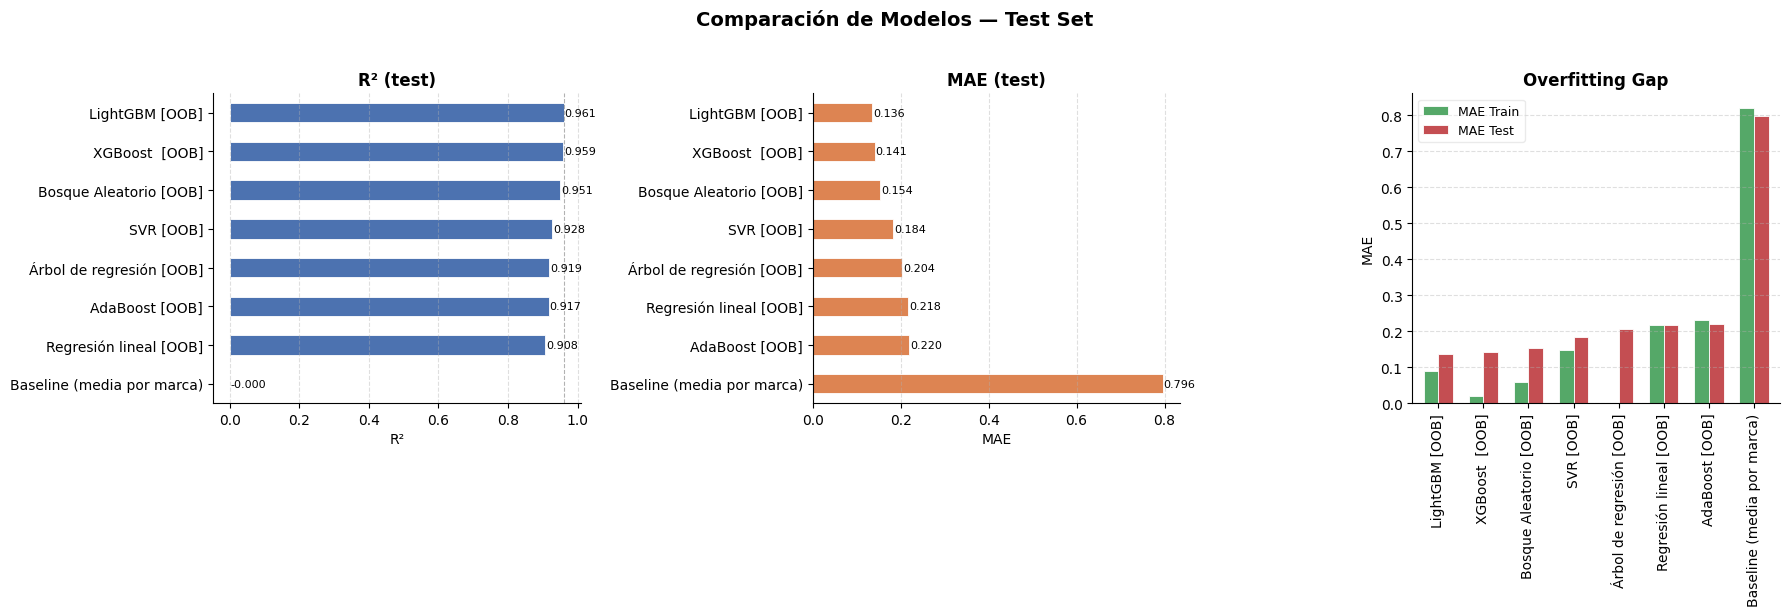

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Modelos — Test Set', fontsize=14, fontweight='bold', y=1.02)

# Paleta de colores
color_r2  = '#4C72B0'
color_mae = '#DD8452'
colors_gap = ['#55A868', '#C44E52']

# --- R² ---
df_r2 = results_df.sort_values('R2').set_index('name')
bars = df_r2['R2'].plot.barh(ax=axes[0], color=color_r2, edgecolor='white', linewidth=0.6)
axes[0].set_title('R² (test)', fontweight='bold')
axes[0].set_xlabel('R²')
axes[0].set_ylabel('')
axes[0].axvline(df_r2['R2'].max(), color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
for bar, val in zip(axes[0].patches, df_r2['R2']):
    axes[0].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=8)

# --- MAE ---
df_mae = results_df.sort_values('MAE', ascending=False).set_index('name')
df_mae['MAE'].plot.barh(ax=axes[1], color=color_mae, edgecolor='white', linewidth=0.6)
axes[1].set_title('MAE (test)', fontweight='bold')
axes[1].set_xlabel('MAE')
axes[1].set_ylabel('')
for bar, val in zip(axes[1].patches, df_mae['MAE']):
    axes[1].text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                 f'{val:.3f}', va='center', fontsize=8)

# --- Overfitting gap ---
df_gap = results_df.set_index('name')[['MAE_training', 'MAE']].sort_values('MAE')
df_gap.columns = ['MAE Train', 'MAE Test']
df_gap.plot.bar(ax=axes[2], color=colors_gap, edgecolor='white', linewidth=0.6, width=0.65)
axes[2].set_title('Overfitting Gap', fontweight='bold')
axes[2].set_xlabel('')
axes[2].set_ylabel('MAE')
axes[2].tick_params(axis='x', rotation=90)
axes[2].legend(framealpha=0.4, fontsize=9)

# Estilo global
for ax in axes:
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x' if ax != axes[2] else 'y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

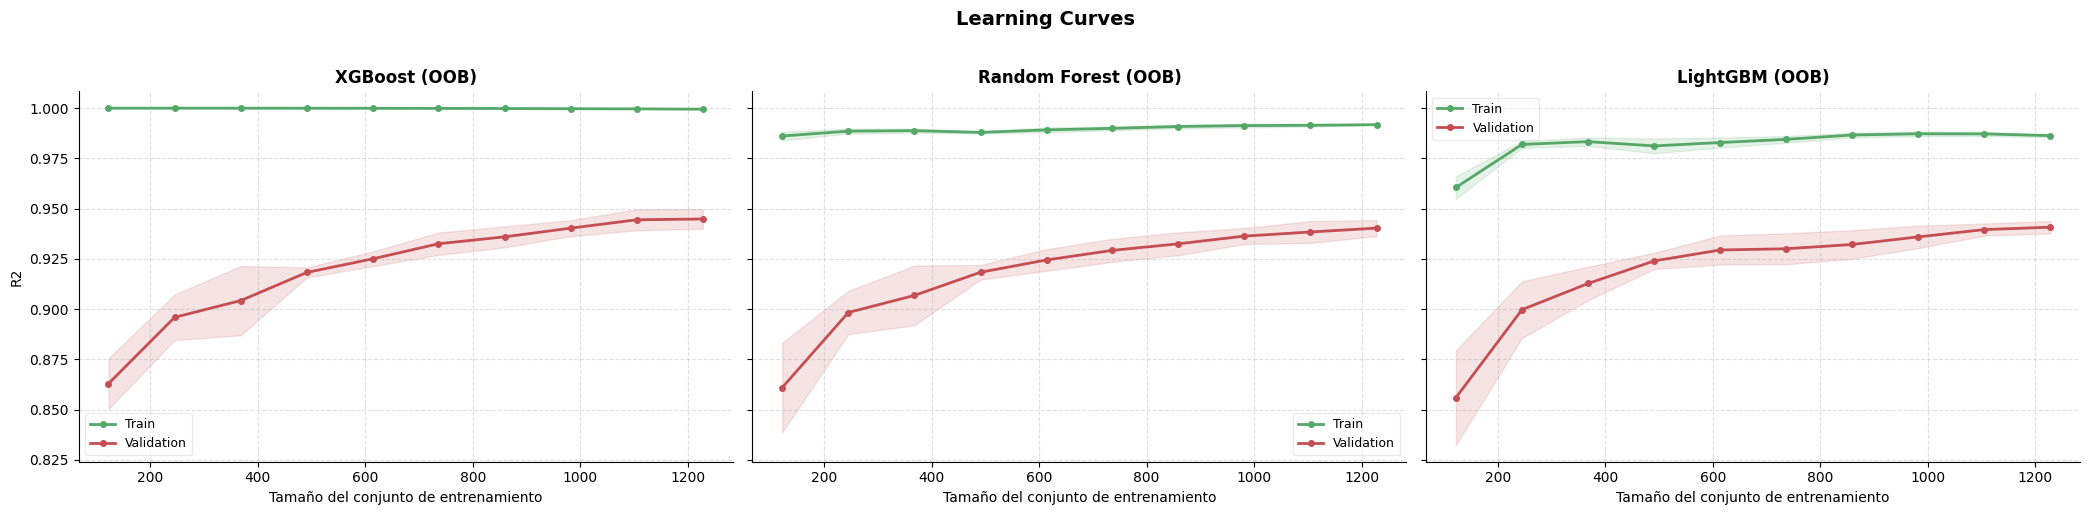

In [22]:
def plot_learning_curves(models: dict, X, y, cv=5, scoring='r2', n_jobs=-1):
    train_sizes = np.linspace(0.1, 1.0, 10)

    fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5), sharey=True)
    fig.suptitle('Learning Curves', fontsize=14, fontweight='bold', y=1.02)

    if len(models) == 1:
        axes = [axes]

    for ax, (name, model) in zip(axes, models.items()):
        train_sz, train_scores, val_scores = learning_curve(
            model, X, y,
            train_sizes=train_sizes,
            cv=cv,
            scoring=scoring,
            n_jobs=n_jobs,
            shuffle=True,
            random_state=42
        )

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)

        # Líneas principales
        ax.plot(train_sz, train_mean, 'o-', color='#55A868', label='Train', linewidth=2, markersize=4)
        ax.plot(train_sz, val_mean,   'o-', color='#C44E52', label='Validation', linewidth=2, markersize=4)

        # Bandas de desviación estándar
        ax.fill_between(train_sz, train_mean - train_std, train_mean + train_std, alpha=0.15, color='#55A868')
        ax.fill_between(train_sz, val_mean   - val_std,   val_mean   + val_std,   alpha=0.15, color='#C44E52')

        ax.set_title(name, fontweight='bold')
        ax.set_xlabel('Tamaño del conjunto de entrenamiento')
        ax.set_ylabel(scoring.upper() if ax == axes[0] else '')
        ax.legend(framealpha=0.4, fontsize=9)
        ax.spines[['top', 'right']].set_visible(False)
        ax.grid(linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()


models_to_plot = {
    "XGBoost (OOB)":       xgb.XGBRegressor(random_state=42, n_jobs=-1),
    "Random Forest (OOB)": RandomForestRegressor(random_state=42),
    "LightGBM (OOB)":      lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
}

plot_learning_curves(models_to_plot, X_train, y_train)

## Ajuste de Hiperparámetros

En base a las métricas de rendimiento de los modelos OOB, se continua con el ajuste de hiperparámetros de los tres modelos con mejor rendimiento: 
- LightGBM
- XGBoost
- Bosques Aleatorios

Se buscan los hiperparámetros óptimos utilizando Randomized Grid Search y Optuna. 

### ¿Por qué Grid Search Y Optuna?

Usamos ambas estrategias para aprovechar sus fortalezas complementarias:

- **Grid Search:** Garantiza explorar todas las combinaciones de una grilla predefinida. Ideal para espacios pequeños con hiperparámetros discretos.
- **Optuna (TPE Sampler):** Optimización bayesiana que aprende de trials anteriores para concentrar la búsqueda en regiones prometedoras. Maneja espacios continuos y grandes (500 trials) de forma eficiente.

Ambos métodos usan cross-validation sobre el conjunto de entrenamiento para evitar sobreajuste al set de test durante la búsqueda.

## Bosque Aleatorio - Grid Search

In [ ]:
# 1. Parameter grid
param_grid = {
    "max_depth": range(1, 11),
    "min_samples_split": range(2, 20, 4),
    "min_samples_leaf": range(1, 10, 5),
    "n_estimators": range(10, 300, 100),
    "n_jobs": [-1],
    "criterion": ["squared_error"],
}

# 2. Base model (static params only)
bosque = RandomForestRegressor(random_state=42)


print("Starting Grid Search...")
cv = 5
grid_search = cached(
    "bosque_aleatorio_grid_search",
    lambda: run_grid_search(X_train, y_train, bosque, param_grid,cv),
)

results["bosque_aleatorio_grid"] = evaluate(
    grid_search.best_estimator_,
    X_train, y_train, X_test, y_test,
    name="Bosque Aleatorio (GridSearch)",
    cache_key="bosque_aleatorio_grid",  # ← different key
)


Starting Grid Search...


## XGBoost — Grid Search

In [24]:
# can we improve xgboost via params?

# 1. Parameter grid
param_grid = {
    "subsample": np.linspace(0.4, 1.0, 10),
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "alpha": np.linspace(0.01, 10, 10),
}

# 2. Base model (static params only)
xgb_base = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)


def run_grid_search(X, y):
    gs = GridSearchCV(
        estimator=xgb_base,
        param_grid=param_grid,
        scoring="neg_mean_absolute_error",
        cv=5,
        verbose=1,
        n_jobs=-1,
    )
    gs.fit(X, y)
    return gs


print("Starting Grid Search...")
grid_search = cached("xgb_grid_search", lambda: run_grid_search(X_train, y_train))
print(f"\nBest parameters found: {grid_search.best_params_}")
print(f"Best cross-validation MAE: {-grid_search.best_score_:.4f}")

results["xgb_grid"] = evaluate(
    grid_search.best_estimator_,
    X_train,
    y_train,
    X_test,
    y_test,
    name="XGBoost (GridSearch)",
    cache_key="xgb_grid",
)


Starting Grid Search...

Best parameters found: {'alpha': np.float64(0.01), 'learning_rate': np.float64(0.10666666666666666), 'subsample': np.float64(0.6000000000000001)}
Best cross-validation MAE: 0.1529


## LightGBM - Grid Search

In [26]:
# 1. Parameter grid
lgbm_param_grid = {
    "subsample": np.linspace(0.4, 1.0, 10),
    "learning_rate": np.linspace(0.01, 0.3, 10),
    "reg_alpha": np.linspace(0.01, 10, 10),
}

# 2. Base model (static params only)
lgbm_base = lgb.LGBMRegressor(objective="regression", random_state=42, verbose=-1)


def run_grid_search(X, y):
    gs = GridSearchCV(
        estimator=lgbm_base,
        param_grid=lgbm_param_grid,
        scoring="neg_mean_absolute_error",
        cv=5,
        verbose=1,
        n_jobs=-1,
    )
    gs.fit(X, y)
    return gs


print("Starting LightGBM Grid Search...")
lgbm_grid_search = cached("lgbm_grid_search", lambda: run_grid_search(X_train, y_train))
print(f"\nBest parameters found: {lgbm_grid_search.best_params_}")
print(f"Best cross-validation MAE: {-lgbm_grid_search.best_score_:.4f}")

results["lgbm_grid"] = evaluate(
    lgbm_grid_search.best_estimator_,
    X_train,
    y_train,
    X_test,
    y_test,
    name="LightGBM (GridSearch)",
    cache_key="lgbm_grid",
)

Starting LightGBM Grid Search...

Best parameters found: {'learning_rate': np.float64(0.1711111111111111), 'reg_alpha': np.float64(0.01), 'subsample': np.float64(0.4)}
Best cross-validation MAE: 0.1612


/Users/marcoslund/git/ceia/aprendizaje_de_maquina/aprendizaje_de_maquina_tp/.venv/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator GridSearchCV from version 1.7.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Bosque Aleatorio — Optuna

In [27]:
rf_search_space = {
    "n_estimators": lambda t: t.suggest_int("n_estimators", 100, 1000),
    "max_depth": lambda t: t.suggest_int("max_depth", 3, 30),
    "min_samples_split": lambda t: t.suggest_int("min_samples_split", 2, 20),
    "min_samples_leaf": lambda t: t.suggest_int("min_samples_leaf", 1, 10),
    "max_features": lambda t: t.suggest_float("max_features", 0.2, 1.0),
    "max_samples": lambda t: t.suggest_float("max_samples", 0.5, 1.0),
}
rf_static_params = {"random_state": 42, "n_jobs": -1, "bootstrap": True}

print("Starting Optuna optimization for Random Forest (5-fold CV)...")
rf_study = tune_with_optuna(
    RandomForestRegressor,
    rf_search_space,
    X_train,
    y_train,
    study_name="rf_optuna_5fold",
    static_params=rf_static_params,
    n_trials=500,
    cv=5,
)
print(f"\nBest parameters found: {rf_study.best_params}")
print(f"Best cross-validation MAE: {rf_study.best_value:.4f}")

results["rf_optuna"] = evaluate(
    RandomForestRegressor(**rf_study.best_params, **rf_static_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="Bosque Aleatorio (Optuna 5-fold CV)",
    cache_key="rf_optuna_5fold",
)

Starting Optuna optimization for Random Forest (5-fold CV)...


[I 2026-04-26 20:51:46,664] Using an existing study with name 'rf_optuna_5fold' instead of creating a new one.



Best parameters found: {'n_estimators': 955, 'max_depth': 14, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5453547109669624, 'max_samples': 0.9987144066035138}
Best cross-validation MAE: 0.1615


## XGBoost - Optuna

In [28]:
# Each value is `lambda trial: trial.suggest_*(...)`. tune_with_optuna calls
# the lambda once per trial to build the params dict.
xgb_search_space = {
    "subsample": lambda t: t.suggest_float("subsample", 0.4, 1.0),
    "learning_rate": lambda t: t.suggest_float("learning_rate", 0.01, 0.3, log=True),
    "alpha": lambda t: t.suggest_float("alpha", 0.01, 10.0, log=True),
    "n_estimators": lambda t: t.suggest_int("n_estimators", 100, 1000),
    "max_depth": lambda t: t.suggest_int("max_depth", 3, 10),
    "min_child_weight": lambda t: t.suggest_int("min_child_weight", 1, 10),
    "gamma": lambda t: t.suggest_float("gamma", 0.0, 5.0),
    "colsample_bytree": lambda t: t.suggest_float("colsample_bytree", 0.5, 1.0),
    "reg_lambda": lambda t: t.suggest_float("reg_lambda", 0.01, 10.0, log=True),
}
xgb_static_params = {"objective": "reg:squarederror", "random_state": 42, "n_jobs": -1}

print("Starting Optuna optimization...")
study = tune_with_optuna(
    xgb.XGBRegressor,
    xgb_search_space,
    X_train,
    y_train,
    study_name="xgb_optuna",
    static_params=xgb_static_params,
    n_trials=500,
    cv=5,
)
print(f"\nBest parameters found: {study.best_params}")
print(f"Best cross-validation MAE: {study.best_value:.4f}")

results["xgb_optuna_5_fold"] = evaluate(
    xgb.XGBRegressor(**study.best_params, **xgb_static_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="XGBoost (Optuna 5_fold CV)",
    cache_key="xgb_optuna_5_fold_cv",
)

[I 2026-04-26 20:51:51,158] Using an existing study with name 'xgb_optuna' instead of creating a new one.


Starting Optuna optimization...

Best parameters found: {'subsample': 0.6231543988391031, 'learning_rate': 0.05703450946815151, 'alpha': 0.0128379779322139, 'n_estimators': 914, 'max_depth': 4, 'min_child_weight': 1, 'gamma': 0.0008390008613099483, 'colsample_bytree': 0.6384394398996774, 'reg_lambda': 0.15417587327774515}
Best cross-validation MAE: 0.1401


## LightGBM — Optuna

In [29]:
lgb_search_space = {
    "num_leaves": lambda t: t.suggest_int("num_leaves", 20, 300),
    "max_depth": lambda t: t.suggest_int("max_depth", 3, 12),
    "learning_rate": lambda t: t.suggest_float("learning_rate", 1e-3, 0.3, log=True),
    "n_estimators": lambda t: t.suggest_int("n_estimators", 100, 1000),
    "subsample": lambda t: t.suggest_float("subsample", 0.4, 1.0),
    "colsample_bytree": lambda t: t.suggest_float("colsample_bytree", 0.4, 1.0),
    "reg_alpha": lambda t: t.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    "reg_lambda": lambda t: t.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
    "min_child_samples": lambda t: t.suggest_int("min_child_samples", 5, 100),
}
lgb_static_params = {"random_state": 42, "n_jobs": -1, "verbose": -1}

print("Starting Optuna optimization for LightGBM (5-fold CV)...")
lgb_study = tune_with_optuna(
    lgb.LGBMRegressor,
    lgb_search_space,
    X_train,
    y_train,
    study_name="lgb_optuna_5fold",
    static_params=lgb_static_params,
    n_trials=500,
    cv=5,
)
print(f"\nBest parameters found: {lgb_study.best_params}")
print(f"Best cross-validation MAE: {lgb_study.best_value:.4f}")

results["lgb_optuna"] = evaluate(
    lgb.LGBMRegressor(**lgb_study.best_params, **lgb_static_params),
    X_train,
    y_train,
    X_test,
    y_test,
    name="LightGBM (Optuna 5-fold CV)",
    cache_key="lgb_optuna_5fold",
)

[I 2026-04-26 20:51:58,240] Using an existing study with name 'lgb_optuna_5fold' instead of creating a new one.


Starting Optuna optimization for LightGBM (5-fold CV)...

Best parameters found: {'num_leaves': 189, 'max_depth': 4, 'learning_rate': 0.04649183447317589, 'n_estimators': 981, 'subsample': 0.7563105528024483, 'colsample_bytree': 0.671786484795114, 'reg_alpha': 0.11422964068498921, 'reg_lambda': 2.685099760329801, 'min_child_samples': 5}
Best cross-validation MAE: 0.1470


In [30]:
results_df = pd.DataFrame(results).T
results_df.sort_values("R2", ascending=False)

,name,MAE_training,MAE,RMSE,MAPE,R2
xgb_optuna_5_fold,XGBoost (Optuna 5_fold CV),0.049465,0.129914,0.17657,0.548095,0.966992
lgb_optuna,LightGBM (Optuna 5-fold CV),0.07244,0.132775,0.178142,0.535485,0.966402
lgbm_grid,LightGBM (GridSearch),0.068081,0.134563,0.186957,0.661561,0.962995
xgb_grid,XGBoost (GridSearch),0.068479,0.136332,0.188051,0.63277,0.96256
lgb_oob,LightGBM [OOB],0.087823,0.135938,0.192004,0.536661,0.96097
rf_optuna,Bosque Aleatorio (Optuna 5-fold CV),0.060467,0.14497,0.194298,0.635879,0.960032
xgb_oob,XGBoost [OOB],0.020545,0.140831,0.197787,0.690452,0.958583
bosque_aleatorio_oob,Bosque Aleatorio [OOB],0.059192,0.154201,0.215698,0.695518,0.950743
bosque_aleatorio_grid,Bosque Aleatorio (GridSearch),0.080189,0.156605,0.218456,0.701019,0.949475
svr_oob,SVR [OOB],0.146412,0.18356,0.261172,0.878957,0.927784


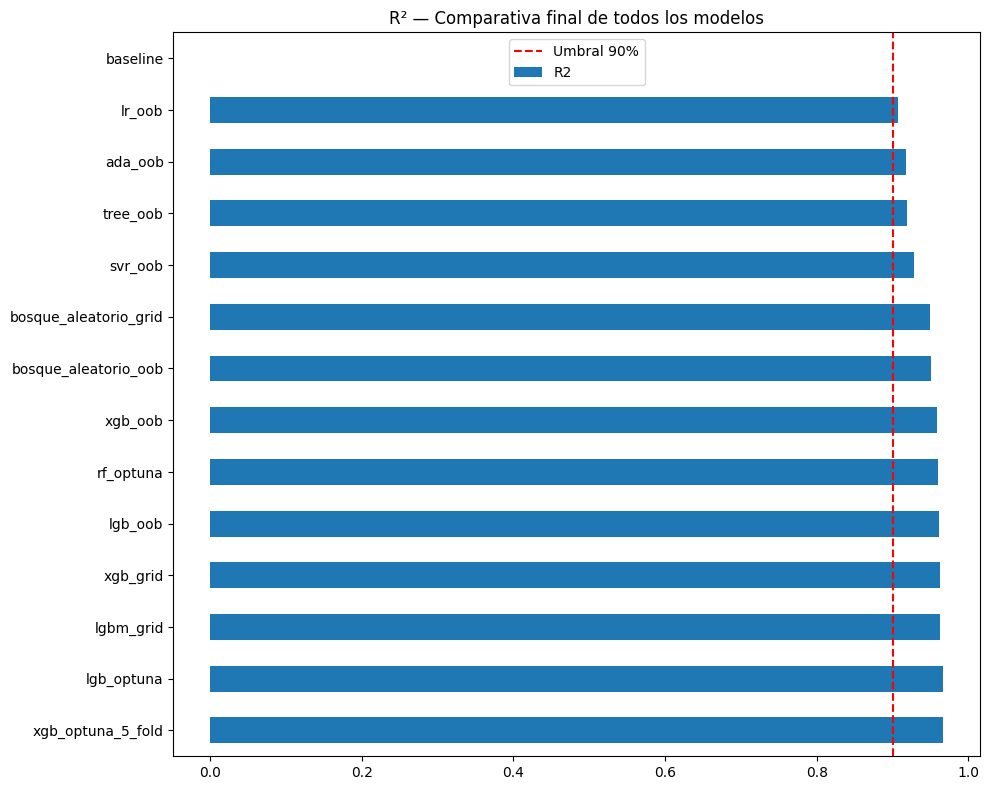

In [31]:
# Comparar todos los modelos en un solo gráfico
final_df = pd.DataFrame(results).T.sort_values("R2", ascending=False)
final_df["R2"].plot.barh(figsize=(10,8), title="R² — Comparativa final de todos los modelos")
plt.axvline(x=0.90, color='red', linestyle='--', label='Umbral 90%')
plt.legend(); plt.tight_layout()

In [32]:
xgb_study = optuna.load_study(
    study_name="xgb_optuna",
    storage=f"sqlite:///{OPTUNA_DB}",
)
best_model = xgb.XGBRegressor(
    **xgb_study.best_params,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
).fit(X_train, y_train)

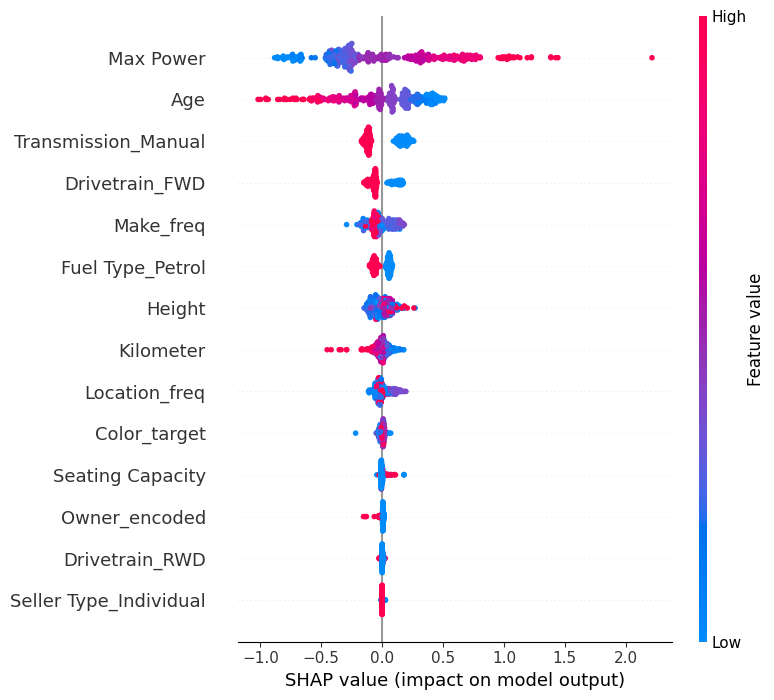

In [33]:
import shap

explainer = shap.TreeExplainer(best_model)  # XGBoost o LightGBM
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

En el eje horizontal, cada punto muestra el valor SHAP de un ejemplo para una variable: indica en cuánto la predicción del modelo se desvía hacia más precio a la derecha y hacia menos a la izquierda respecto del valor de base. El color de cada punto es el valor real de la variable en ese registro: rojo = valor alto, azul = valor bajo (en el espacio de `X_test` ya transformado y estandarizado).

- **Max Power** se extiende en un rango ancho a lo largo del eje: el árbol asigna a la potencia el mayor margen de explicación del precio en el conjunto de prueba. El patrón con azul a la izquierda y rojo a la derecha indica que baja potencia empuja el precio predicho hacia abajo  y alta potencia hacia arriba, coherente con segmentos más costosos o deseables.
- **Age** abarca un poco menos de extensión horizontal, pero con colores con sentido opuesto: más antigüedad a la izquierda y valores jóvenes a la derecha, alineado con la depreciación de un usado.
- El **resto** de atributos tiene nubes más estrechas en el eje X: el efecto agregado es de menor amplitud, pero la diferencia rojo/azul en muchas filas muestra que el modelo sí emplea esas señales (p. ej. km, marca, ubicación) aunque no concentre tanto el peso explicativo como potencia o edad.


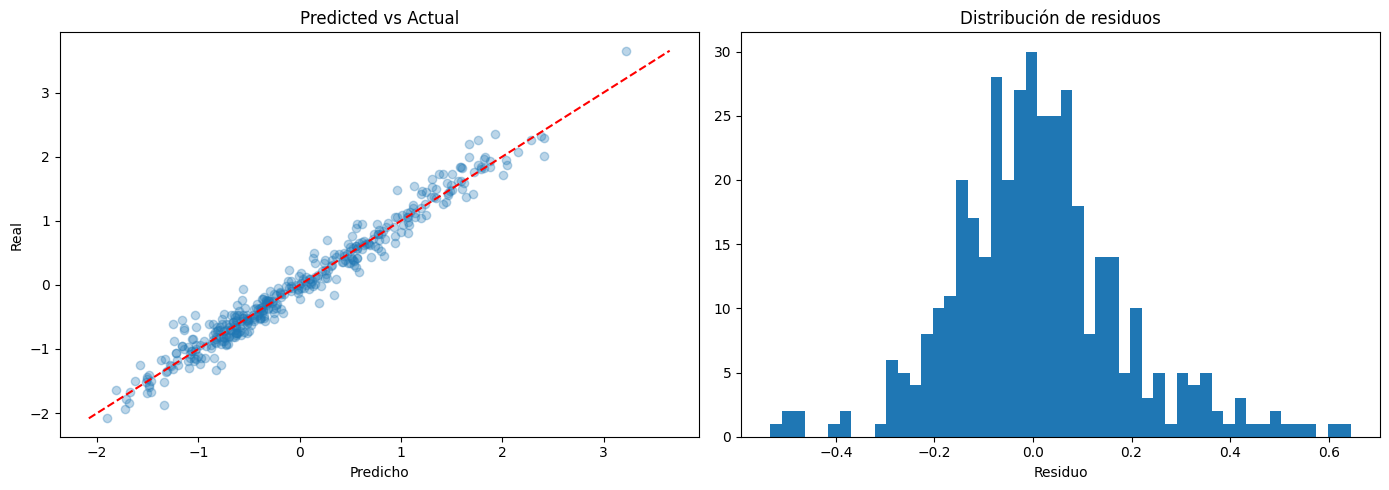

In [34]:
y_pred = best_model.predict(X_test)
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y_pred, y_test, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[0].set(xlabel="Predicho", ylabel="Real", title="Predicted vs Actual")

axes[1].hist(residuals, bins=50)
axes[1].set(xlabel="Residuo", title="Distribución de residuos")
plt.tight_layout()

En la práctica, las predicciones se alinean con la identidad (puntos cerca de la línea punteada), con casi nulos valores atípicos, y el histograma concentra los residuos en torno a 0: apoya un ajuste global coherente; en línea con un R² de test por encima de 0,96 en el mejor modelo.


<a id="commentary-and-conclusions"></a>

# Conclusiones

In [35]:
results_df = pd.DataFrame(results).T

results_df.sort_values("R2", ascending=False)

,name,MAE_training,MAE,RMSE,MAPE,R2
xgb_optuna_5_fold,XGBoost (Optuna 5_fold CV),0.049465,0.129914,0.17657,0.548095,0.966992
lgb_optuna,LightGBM (Optuna 5-fold CV),0.07244,0.132775,0.178142,0.535485,0.966402
lgbm_grid,LightGBM (GridSearch),0.068081,0.134563,0.186957,0.661561,0.962995
xgb_grid,XGBoost (GridSearch),0.068479,0.136332,0.188051,0.63277,0.96256
lgb_oob,LightGBM [OOB],0.087823,0.135938,0.192004,0.536661,0.96097
rf_optuna,Bosque Aleatorio (Optuna 5-fold CV),0.060467,0.14497,0.194298,0.635879,0.960032
xgb_oob,XGBoost [OOB],0.020545,0.140831,0.197787,0.690452,0.958583
bosque_aleatorio_oob,Bosque Aleatorio [OOB],0.059192,0.154201,0.215698,0.695518,0.950743
bosque_aleatorio_grid,Bosque Aleatorio (GridSearch),0.080189,0.156605,0.218456,0.701019,0.949475
svr_oob,SVR [OOB],0.146412,0.18356,0.261172,0.878957,0.927784


### 1. XGBoost ajustado con Optuna resultó ser el mejor modelo

Los modelos de gradient boosting (XGBoost y LightGBM) dominaron la tabla de resultados en todas las métricas. Con hiperparámetros optimizados vía Optuna, XGBoost alcanzó R² = 0.967 y LightGBM R² = 0.966 sobre el conjunto de test, superando a Random Forest (R² ≈ 0.960), SVR (R² ≈ 0.928) y Regresión Lineal (R² ≈ 0.908).

Esto se debe a que se construyen árboles de forma secuencial, corrigiendo el residuo del modelo anterior en cada paso. Esta propiedad le permite capturar las interacciones no lineales propias del mercado de usados, como la depreciación diferencial por marca o el impacto de la potencia según antigüedad, que los modelos lineales no pueden representar con la misma riqueza.

La hipótesis técnica inicial quedó confirmada: los ensambles de árboles superaron a los modelos lineales.

### 2. La importancia de la potencia de motor y antigüedad del vehículo

El análisis SHAP sobre el mejor modelo (XGBoost con Optuna) identificó las siguientes variables como los principales determinantes del precio:

- **`Max Power` (potencia máxima):** el predictor con mayor dispersión de contribuciones SHAP. Alta potencia empuja la predicción hacia precios más altos de forma consistente; baja potencia hacia valores más bajos. Captura el segmento de mercado mejor que cualquier otra variable individual.
- **`Age` (antigüedad del vehículo):** segunda variable en magnitud de efecto. Mayor antigüedad reduce sistemáticamente el precio predicho, reflejando la depreciación temporal esperada.
- **`Kilometer` (kilometraje):** el uso acumulado y la eficiencia de combustible aportan señal adicional sobre el estado y costo de operación del vehículo.
- **`Make` (marca)**: no se observa una relación fuerte entre la marca de un vehículo y su precio.

Las hipótesis de negocio iniciales se corroboraron parcialmente: la antigüedad y el kilometraje sí correlacionan con precios más bajos, y la marca tiene influencia —aunque menor a la esperada frente a variables técnicas como la potencia.

### 3. El análisis de componentes principales no aportó ningún beneficio

**PCA no aportó ningún beneficio.** En todos los experimentos, las variantes con PCA rindieron por debajo de sus equivalentes con features completas. Con aproximadamente 14 columnas predictivas y más de 1.500 filas de entrenamiento, la relación filas/columnas (~107:1) no presenta la maldición de la dimensionalidad que motivaría una reducción. La hipótesis técnica inicial quedó confirmada: PCA fue descartado en favor del dataset completo.

### 4. Se obtuvieron mejoras al ajustar hiperparámetros

El ajuste de hiperparámetros produjo mejoras consistentes sobre los valores por defecto (OOB), pero la magnitud varió según el método:

| Configuración | R² (XGBoost) | R² (LightGBM) | R² (Random Forest) |
|---|---|---|---|
| OOB (valores por defecto) | ~0.948 | ~0.946 | ~0.950 |
| Grid Search (5-fold CV) | ~0.963 | ~0.962 | ~0.955 |
| **Optuna TPE (500 trials, 5-fold CV)** | **0.967** | **0.966** | **~0.960** |

**Optuna superó a Grid Search** en los tres modelos. La ventaja de la optimización bayesiana (sampler TPE) sobre la grilla discreta es especialmente marcada cuando el espacio de búsqueda es amplio y continuo.

El ajuste también redujo el gap de overfitting: los modelos OOB mostraban MAE de entrenamiento significativamente menor que en test; las variantes tuneadas con cross-validation acercaron ambas curvas sin sacrificar rendimiento en test. La hipótesis técnica inicial quedó confirmada para el árbol de decisión individual (overfitting severo, MAE train ≈ 0) y extendida: el tuning con Optuna demostró ser la estrategia más eficiente para los modelos de boosting.

En particular, con XGBoost el control de sobreajuste vino por dos vías indirectas. Por un lado, la profundidad acotada (`max_depth = 6`) limitó la complejidad individual de cada árbol. Por el otro, un learning rate bajo con muchos árboles (`learning_rate = 0.04`, `n_estimators = 797`) logró que cada árbol aporte poco al ensemble, mejorando la generalización.

### 5. Conclusión final

El trabajo demostró que es posible construir un modelo de predicción de precios de autos usados con alta precisión y utilidad práctica. **XGBoost optimizado con Optuna** es el modelo recomendado: R² = 0.967.

Desde la perspectiva del problema de negocio, un error del orden de las 70.000 rupias sobre precios que pueden superar el millón representa una precisión suficiente para asistir a vendedores en la fijación de precios y a compradores en la detección de sobreprecios. Las variables técnicas —potencia y antigüedad— resultan más determinantes que la marca o el tipo de transmisión, lo que implica que una plataforma de valuación automática puede operar con información objetiva del vehículo sin depender de señales de mercado difíciles de obtener.

Como extensiones naturales se proponen: (1) explorar **stacking** de los tres mejores modelos, (2) evaluar arquitecturas de redes neuronales para datos tabulares, (3) adaptar el pipeline a datos del mercado local donde la estructura de precios y oferta de marcas difiere, y (4) incorporar **reentrenamiento periódico** para mantener la vigencia del modelo ante cambios de mercado.